In [433]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftshift
from scipy.signal import convolve2d

from Functions import *
from fftwave import fftwave

In [434]:
import matplotlib.pyplot as plt
import numpy as np

def create_plots(rows, cols, image_list, row_list=None, col_list=None,
                 figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15):
    """
    Display images in a grid with optional row and column titles.
    Column titles are placed on the top row (via set_title).
    Row titles are added as rotated figure text on the left.
    """

    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0],
                                                  rows * figsize_per_image[1]))
    axes = np.atleast_2d(axes)

    img_idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
            plt.sca(ax)

            if img_idx >= len(image_list):
                ax.axis("off")
                continue

            showgrey(image_list[img_idx], display=False)

            # Column titles
            if col_list and r == 0 and c < len(col_list):
                ax.set_title(col_list[c], fontsize=title_fontsize)

            img_idx += 1

    # Add row labels as rotated figure text
    if row_list:
        fig.tight_layout()  # ensure positions are up-to-date before reading bbox
        fig.canvas.draw()   # necessary to get correct positions in some backends

        # Find the leftmost x position of the first column
        left_edge = min(ax.get_position().x0 for ax in axes[:, 0])
        x_text = left_edge - 0.02  # small offset to the left

        for r, label in enumerate(row_list[:rows]):
            ax0 = axes[r, 0]
            bbox = ax0.get_position()
            ycenter = (bbox.y0 + bbox.y1) / 2
            plt.figtext(x_text, ycenter, label, fontsize=label_fontsize,
                        va='center', ha='center', rotation=90)
    else:
        plt.tight_layout()

    plt.show()




## 1 Properties of the discrete Fourier transform
### 1.3 Basis Functions

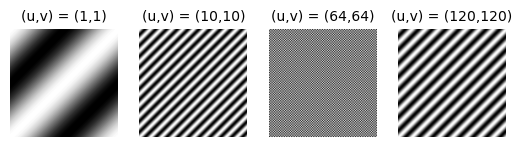

In [435]:
plt.subplot(1,4,1)
u, v = 1,1

plt.title('(u,v) = (' + str(u) + ',' +str(v) + ')')
Fhat = np.zeros([128, 128])
Fhat[u, v] = 1
F = np.fft.ifft2(Fhat)
Fabsmax = np.max(np.abs(F))
showgrey(np.real(F), False, 64, -Fabsmax, Fabsmax)

plt.subplot(1,4,2)
u, v = 10,10

plt.title('(u,v) = (' + str(u) + ',' +str(v) + ')')
Fhat = np.zeros([128, 128])
Fhat[u, v] = 1
F = np.fft.ifft2(Fhat)
Fabsmax = np.max(np.abs(F))
showgrey(np.real(F), False, 64, -Fabsmax, Fabsmax)

plt.subplot(1,4,3)
u, v = 64,64

plt.title('(u,v) = (' + str(u) + ',' +str(v) + ')')
Fhat = np.zeros([128, 128])
Fhat[u, v] = 1
F = np.fft.ifft2(Fhat)
Fabsmax = np.max(np.abs(F))
showgrey(np.real(F), False, 64, -Fabsmax, Fabsmax)

plt.subplot(1,4,4)
u, v = 120,120

plt.title('(u,v) = (' + str(u) + ',' +str(v) + ')')
Fhat = np.zeros([128, 128])
Fhat[u, v] = 1
F = np.fft.ifft2(Fhat)
Fabsmax = np.max(np.abs(F))
showgrey(np.real(F), False, 64, -Fabsmax, Fabsmax)

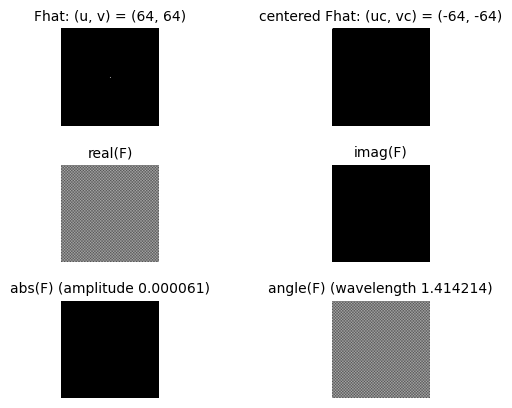

In [436]:
fftwave(64,64)

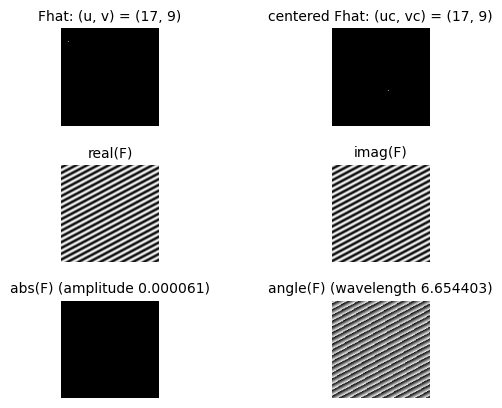

In [437]:
fftwave(17, 9)

### 1.4 Linearity

In [438]:
F4 = np.concatenate([np.zeros((56,128)), np.ones((16,128)), np.zeros((56,128))])
G4 = F4.T
H4 = F4 + 2*G4

Fhat = fft2(F4)
Ghat = fft2(G4)
Hhat = fft2(H4)

[]

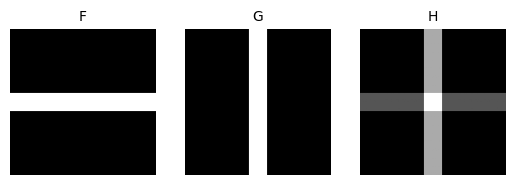

In [439]:
plt.subplot(1,3,1)
showgrey(F4, display=False)
plt.title('F')

plt.subplot(1,3,2)
showgrey(G4, display=False)
plt.title('G')

plt.subplot(1,3,3)
showgrey(H4, display=False)
plt.title('H')

plt.plot()

[]

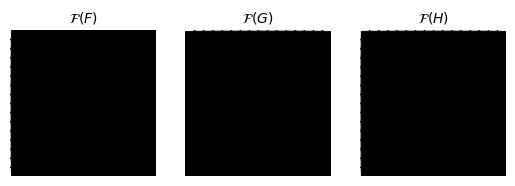

In [440]:
plt.subplot(1,3,1)
showgrey(np.log(1 + np.abs(Fhat)), display=False)
plt.title(r'$\mathcal{F}(F)$')

plt.subplot(1,3,2)
showgrey(np.log(1 + np.abs(Ghat)), display=False)
plt.title(r'$\mathcal{F}(G)$')

plt.subplot(1,3,3)
showgrey(np.log(1 + np.abs(Hhat)), display=False)
plt.title(r'$\mathcal{F}(H)$')

plt.plot()

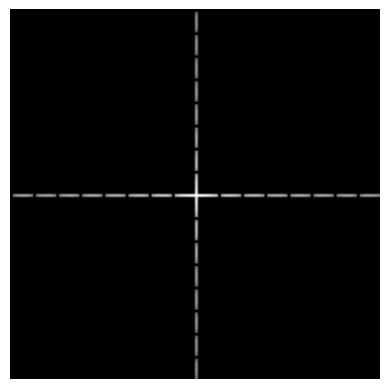

In [441]:
showgrey(np.log(1 + np.abs(fftshift(Hhat))))

### 1.5 Multiplication

[]

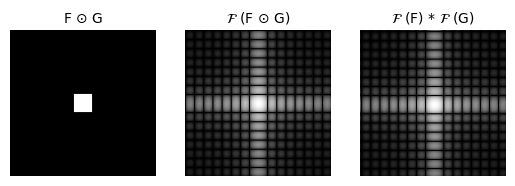

In [476]:
plt.subplot(1,3,1)
showgrey(F4 * G4, display=False)
plt.title(r'F $\odot$ G')
plt.subplot(1,3,2)
showfs(fft2(F4 * G4), display=False)
plt.title(r'$\mathcal{F}$ (F $\odot$ G)')
plt.subplot(1,3,3)
plt.title(r'$\mathcal{F}$ (F) * $\mathcal{F}$ (G)')
convolution = convolve2d(Fhat,Ghat, boundary='wrap', mode='same')
convolution /= (len(G4) ** 2)
showfs(fftshift(convolution), display=False)
#showgrey(np.log(1 + np.abs(convolution)), display=False)

plt.plot()

### 1.6 Scaling

[]

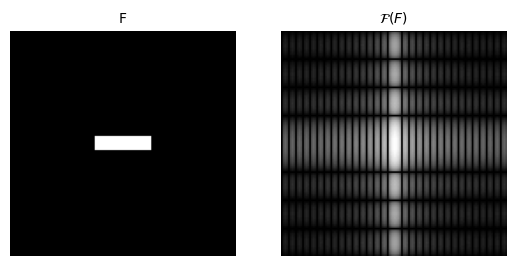

In [444]:
F6 = np.concatenate([np.zeros((60,128)), np.ones((8,128)), np.zeros((60,128))]) * \
np.concatenate([np.zeros((128,48)), np.ones((128,32)), np.zeros((128,48))], axis=1)

plt.subplot(1,2,1)
showgrey(F6, display=False)
plt.title('F')

plt.subplot(1,2,2)
showfs(fft2(F6), display=False)
plt.title(r'$\mathcal{F}(F)$')

plt.plot()

[]

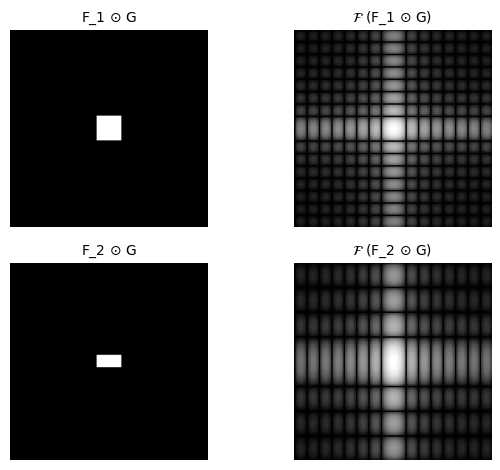

In [445]:
plt.subplot(2,2,1)
showgrey(F4 * G4, display=False)
plt.title(r'F_1 $\odot$ G')

plt.subplot(2,2,2)
showfs(fft2(F4 * G4), display=False)
plt.title(r'$\mathcal{F}$ (F_1 $\odot$ G)')

plt.subplot(2,2,3)
showgrey(F6 * G4, display=False)
plt.title(r'F_2 $\odot$ G')

plt.subplot(2,2,4)
showfs(fft2(F6 * G4), display=False)
plt.title(r'$\mathcal{F}$ (F_2 $\odot$ G)')

plt.tight_layout()
plt.plot()

### 1.7 Rotation

In [446]:
def get_rotations(alpha):
    G_rot = rot(F4, alpha)
    G_rot_hat = fft2(G_rot)
    H_rot_hat = rot(fftshift(G_rot_hat), -alpha )
    return G_rot, G_rot_hat, H_rot_hat

[]

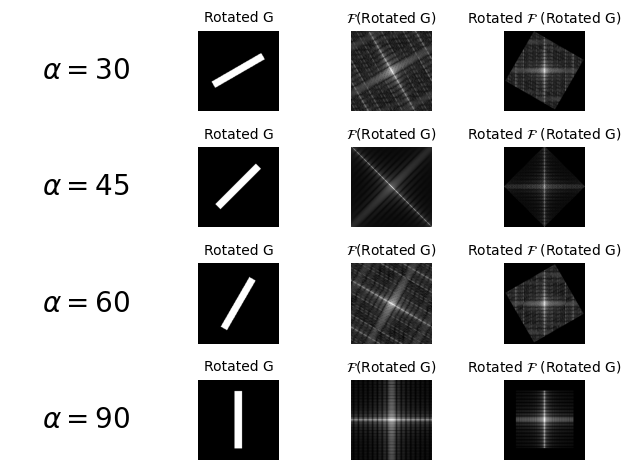

In [447]:
G30, Gr30, H30 = get_rotations(30)
G45, Gr45, H45 = get_rotations(45)
G60, Gr60, H60 = get_rotations(60)
G90, Gr90, H90 = get_rotations(90)


plt.subplot(4,4,1)
plt.text(0.5, 0.5, r'$\alpha = 30$', fontsize=20, ha='center', va='center', color='black')
plt.axis('off')

plt.subplot(4,4,2)
showgrey(G30, display=False)
plt.title('Rotated G')

plt.subplot(4,4,3)
showfs(Gr30, display=False)
plt.title(r'$\mathcal{F}$(Rotated G)')

plt.subplot(4,4,4)
showgrey(np.log(1 + abs(H30)), display=False)
plt.title(r'Rotated $\mathcal{F}$ (Rotated G)')

plt.subplot(4,4,5)
plt.text(0.5, 0.5, r'$\alpha = 45$', fontsize=20, ha='center', va='center', color='black')
plt.axis('off')

plt.subplot(4,4,6)
showgrey(G45, display=False)
plt.title('Rotated G')

plt.subplot(4,4,7)
showfs(Gr45, display=False)
plt.title(r'$\mathcal{F}$(Rotated G)')

plt.subplot(4,4,8)
showgrey(np.log(1 + abs(H45)), display=False)
plt.title(r'Rotated $\mathcal{F}$ (Rotated G)')

plt.subplot(4,4,9)
plt.text(0.5, 0.5, r'$\alpha = 60$', fontsize=20, ha='center', va='center', color='black')
plt.axis('off')

plt.subplot(4,4,10)
showgrey(G60, display=False)
plt.title('Rotated G')

plt.subplot(4,4,11)
showfs(Gr60, display=False)
plt.title(r'$\mathcal{F}$(Rotated G)')

plt.subplot(4,4,12)
showgrey(np.log(1 + abs(H60)), display=False)
plt.title(r'Rotated $\mathcal{F}$ (Rotated G)')

plt.subplot(4,4,13)
plt.text(0.5, 0.5, r'$\alpha = 90$', fontsize=20, ha='center', va='center', color='black')
plt.axis('off')

plt.subplot(4,4,14)
showgrey(G90, display=False)
plt.title('Rotated G')

plt.subplot(4,4,15)
showfs(Gr90, display=False)
plt.title(r'$\mathcal{F}$(Rotated G)')

plt.subplot(4,4,16)
showgrey(np.log(1 + abs(H90)), display=False)
plt.title(r'Rotated $\mathcal{F}$ (Rotated G)')

plt.tight_layout()
plt.plot()

### 1.8 Info, phase and magnitude

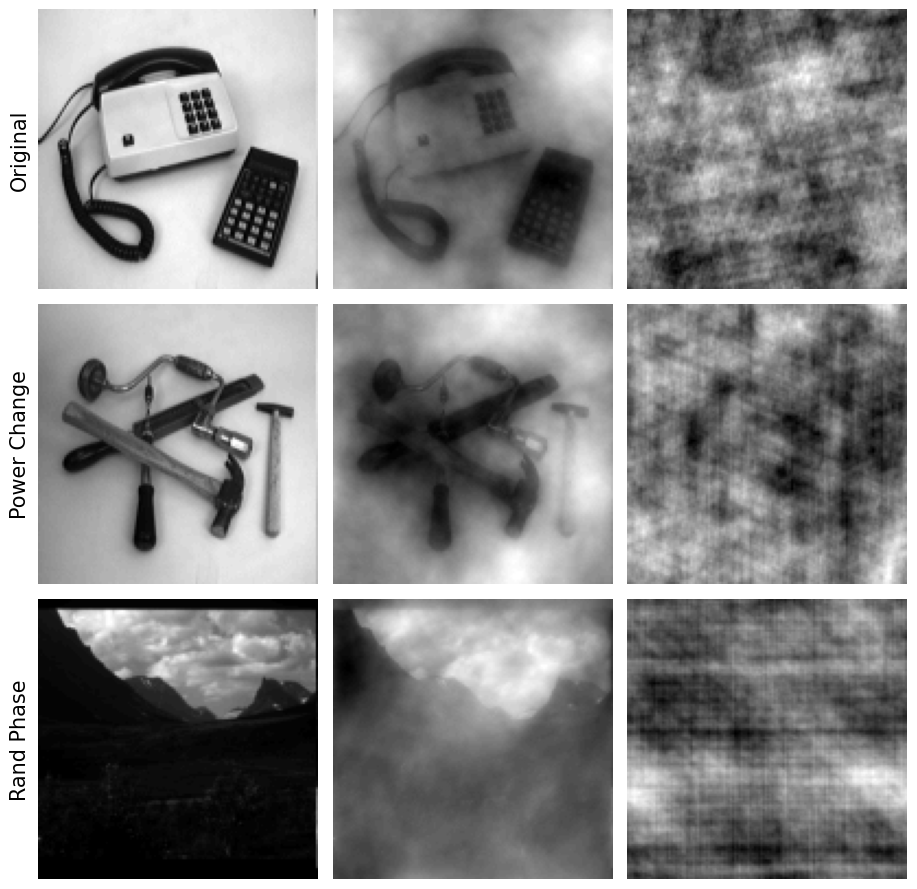

In [449]:
img1 = np.load("./Images-npy/phonecalc128.npy")
img2 = np.load("./Images-npy/few128.npy")
img3 = np.load("./Images-npy/nallo128.npy")

images = [
    img1, pow2image(img1, 1e-3), randphaseimage(img1),
    img2, pow2image(img2, 1e-3), randphaseimage(img2),
    img3, pow2image(img3, 1e-3), randphaseimage(img3)
]

row_titles = ['Original', 'Power Change', 'Rand Phase']

create_plots(3, 3, images, row_list=row_titles)

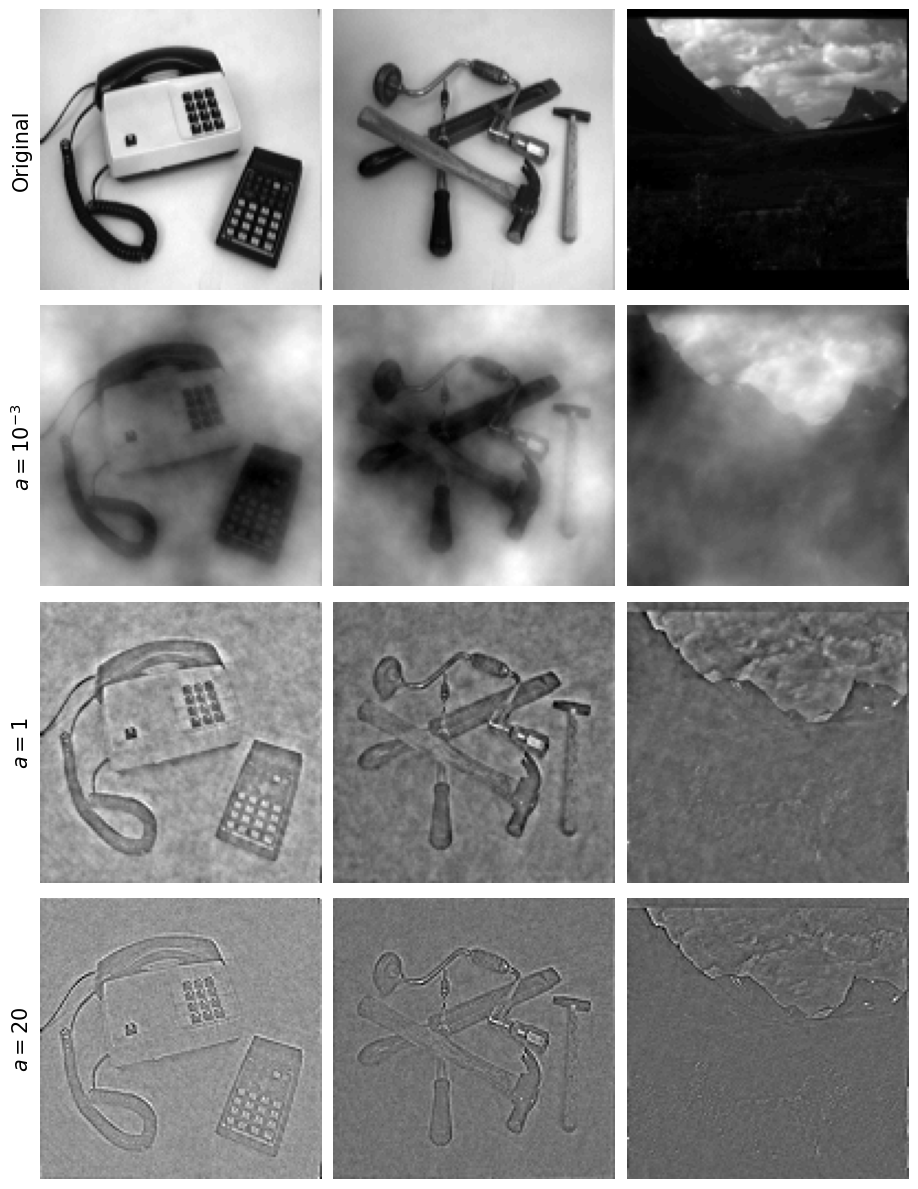

In [450]:
img1 = np.load("./Images-npy/phonecalc128.npy")
img2 = np.load("./Images-npy/few128.npy")
img3 = np.load("./Images-npy/nallo128.npy")

a1 = 1e-3
a2 = 1 
a3 = 20

images = [
    img1, img2, img3,
    pow2image(img1, a1), pow2image(img2, a1), pow2image(img3, a1),
    pow2image(img1, a2), pow2image(img2, a2), pow2image(img3, a2), 
    pow2image(img1, a3), pow2image(img2, a3), pow2image(img3, a3) 
    
]

row_titles = ['Original', r'$a=10^{-3}$', r'$a=1$', r'$a=20$']

create_plots(4, 3, images, row_list=row_titles)

## 2 Gaussian convolution

### 2.1 Continuous Gaussian convolution

In [451]:
def gaussfft(pic, t):
    
    ## Gaussian kernel
    Nx, Ny = pic.shape
    x = np.arange(0, Ny)
    y = np.arange(0, Nx)
    X, Y = np.meshgrid(x, y)
    X = X - Ny/2
    Y = Y - Nx/2

    gaussian_kernel = np.exp(-(X**2 + Y**2)/(2*t))
    gaussian_kernel /= np.sum(gaussian_kernel)

    ## Move origin of filter to corner (0,0)
    gaussian_kernel = np.fft.ifftshift(gaussian_kernel)

    ## Compute convolution
    F = fft2(pic)
    FG = fft2(gaussian_kernel)
    return np.real(ifft2(F * FG)) 

In [452]:
psf = gaussfft(deltafcn(128, 128), 0.1)
variance(psf)

array([[1.32967252e-02, 2.94209102e-15],
       [2.94209102e-15, 1.32967252e-02]])

0.013296725182590619
0.2810538300883838
0.9999997887729095
10.000000000002098
99.99999932823117


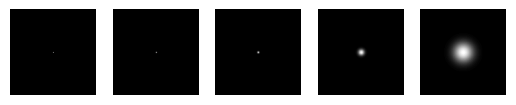

In [453]:
t_vec = [0.1, 0.3, 1.0, 10.0, 100.0]
for i in range(len(t_vec)):
    plt.subplot(1,5,i+1)
    psf = gaussfft(deltafcn(128, 128), t_vec[i])
    showgrey(psf, display=False)

    var = variance(psf)
    print(var[0,0])

plt.show()

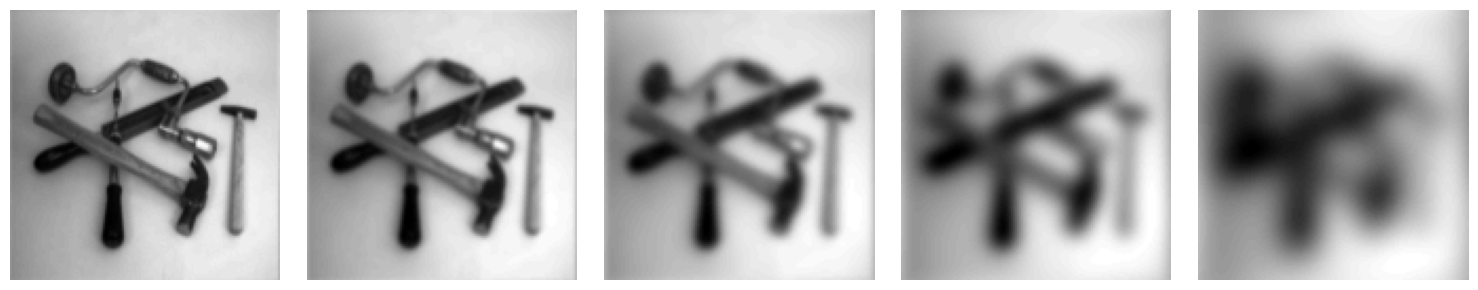

In [454]:
img = np.load("./Images-npy/few128.npy")

l = []
for a in [0.3, 1, 4, 16, 65]:
    l.append(gaussfft(img,a))

create_plots(1,5,l)


## Smoothing

### 3.1 Smoothing noisy data

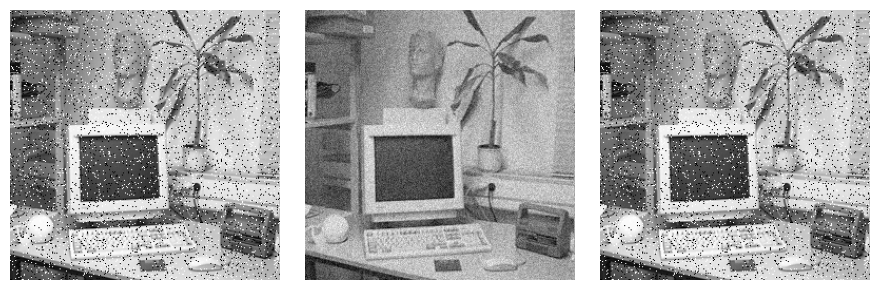

In [455]:
office = np.load("./Images-npy/office256.npy")
add = gaussnoise(office, 16)
sap = sapnoise(office, 0.1, 255)

create_plots(1,3, [office, add, sap])

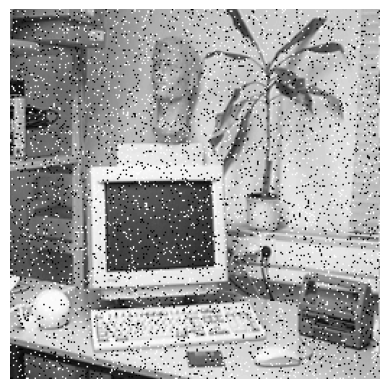

In [456]:
showgrey(sap)

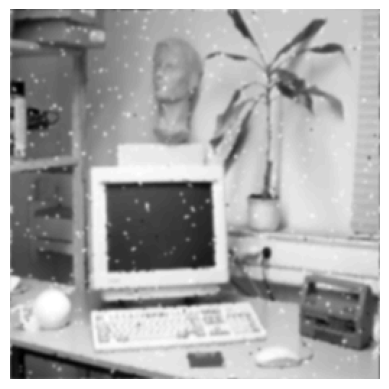

In [457]:
showgrey(gaussfft(medfilt(sap,2), 1))

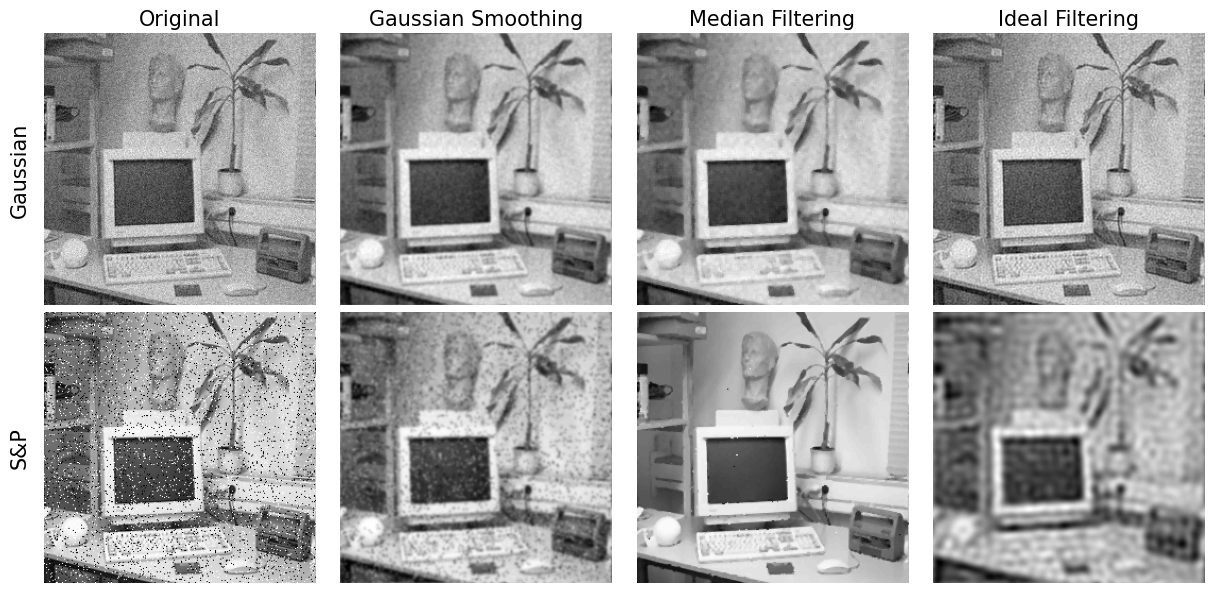

In [458]:

img_list = [
    add, gaussfft(add, 0.9), medfilt(add, 4), ideal(add, 0.4),
    sap, gaussfft(sap, 1.3), medfilt(sap, 3), ideal(sap, 0.1)
    ]

row_titles = ['Gaussian', 'S&P']
col_titles = ['Original', 'Gaussian Smoothing', 'Median Filtering', 'Ideal Filtering']


create_plots(2,4, img_list, row_list=row_titles, col_list=col_titles)

### 3.2 Subsampling

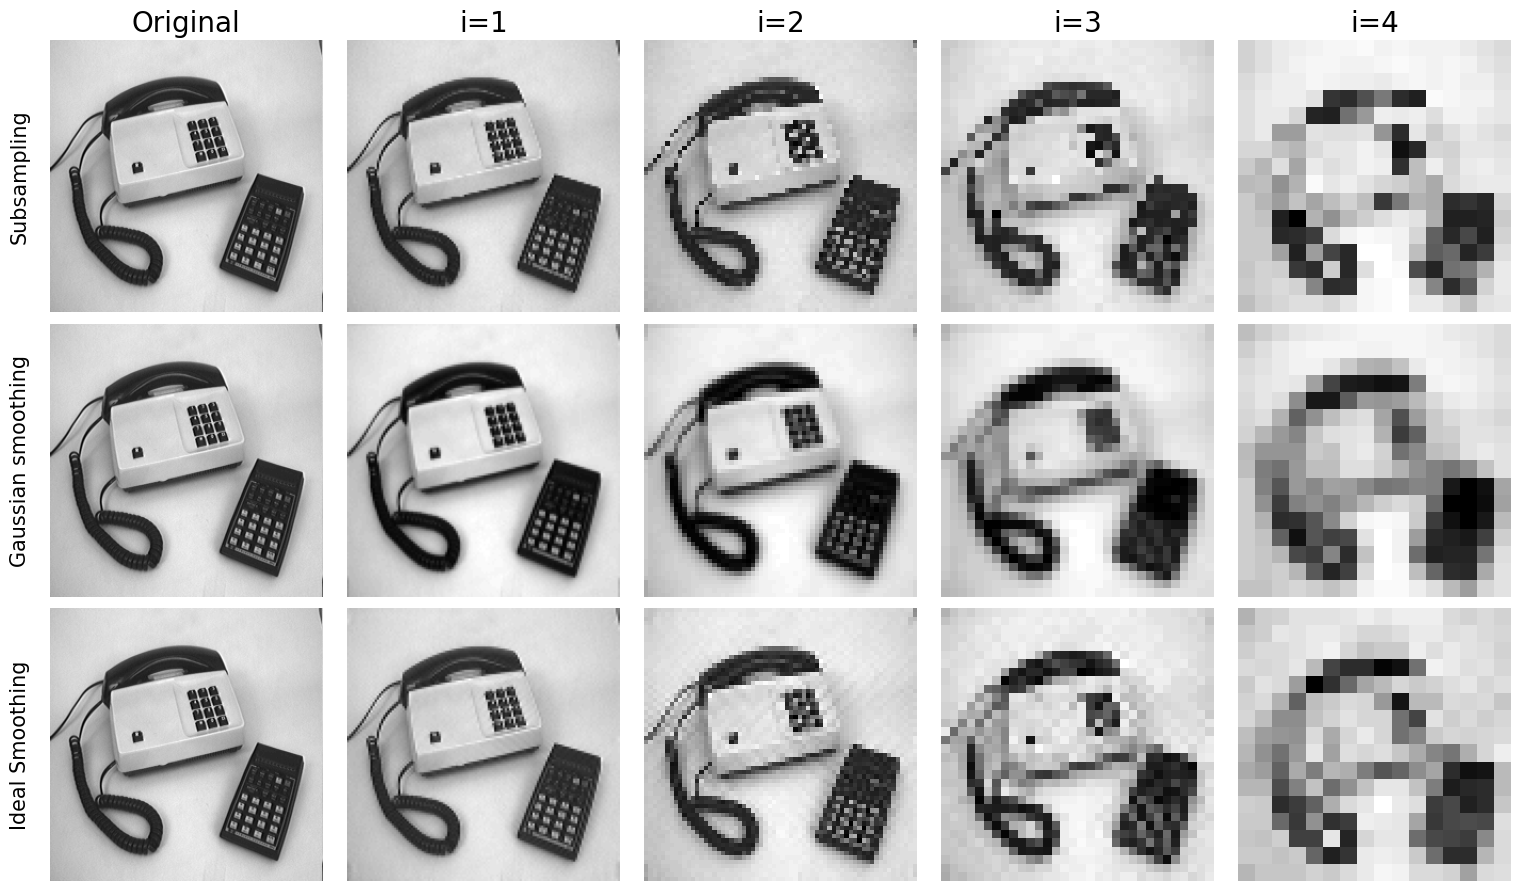

In [459]:
img = np.load("Images-npy/phonecalc256.npy")
g_smoothimg = img
l_smoothing = img
N = 5

r1 = [img]
r2 = [g_smoothimg]
r3 = [l_smoothing]

for i in range(N):
    if i>0: # generate subsampled versions
        img = rawsubsample(img)
        g_smoothimg = rawsubsample(gaussfft(g_smoothimg, 0.5))
        l_smoothing = rawsubsample(ideal(l_smoothing, 0.4))

        r1.append(img)
        r2.append(g_smoothimg)
        r3.append(l_smoothing)

create_plots(3,N, [*r1, *r2, *r3], 
             row_list=['Subsampling', 'Gaussian smoothing', 'Ideal Smoothing'], 
             col_list=['Original', 'i=1', 'i=2', 'i=3', 'i=4'],
             label_fontsize=15,
             title_fontsize=20)